Gotta make some tuning curves for homings. 
Two types of plots:
- tuning curves, by condition sorted for that condition and the sorting applied to the other two conditions
- scatter of peak firing of each neuron across conditions

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

#JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# 
experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

#
trials = [[1,3],[1,5,7],[1],[2],
    [2,3],[1,3],
    [1,3,4],[1,2,3],[1,2],[1,3],
    [4,5],[1,3],[3,4],[4,5],[2,5],
    [1,3],[1,2],[1,3],[5,7,8],[3,5],
]

In [ ]:
%load_ext autoreload
from JR_test_scripts.escape.functions.escape_utils import load, load_homing
from JR_test_scripts.escape.functions.escape_data_loading_funcs import extract_homing_and_escape_periods, extract_non_homing_escape_periods
from JR_test_scripts.escape.functions.escape_plotting_funcs import tuning_curve_by_condition, plot_pref_firing_condition, plot_tuning_matrix, tuning_curve_compare, xval_compare
from JR_test_scripts.escape.functions.escape_tuning_funcs import neuron_tuning_by_var, compute_r_squared, single_trial_tuning

import numpy as np

In [ ]:
"""Make plots for the neurons using their tuning curves for sorting. Plot only neurons with xval tuning curves or all neurons"""

%autoreload 2
compression_var = ['y_pos', 'distance_shelter', 'escape','speed']
for i, exp in enumerate(experiments_objects[13:]):
    # load data
    session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
    ons, offs, homie = load_homing(session, len(behave))
    for comp in compression_var:
        
        nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
        var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, comp, ons, offs, return_escape = True)
        
        # eliminate neurons that are all NaN (they probably didn't fire at all during homing/escape)
        bad_neurons = np.all(np.isnan(escape_matrix), axis=1)
        escape_matrix = escape_matrix[~bad_neurons,:]
        frame_by_cluster_matrix = frame_by_cluster_matrix[:,~bad_neurons]
        
        # make tuning plots for neurons with xval tuning curves only
        peak_firing_condition, tuning, xval = neuron_tuning_by_var(var, escape_matrix, cond, h_start)
        dump_path = "Z:/Jasmine_Laurence/summary_plots/all_trials/xval_tuning" # saving folder name!
        plot_pref_firing_condition(peak_firing_condition, xval, nickname + '_peak_firing', dump_path)
        tuning_curve_by_condition(tuning, xval, nickname + '_tuning', dump_path)
        plot_tuning_matrix(tuning, cond, comp, escape_matrix, var, esc_start, h_start, xval, nickname + '_traces_sorted_tuning', dump_path)

        # make the same plots but for all neurons
        xval = np.ones((np.shape(escape_matrix)[0], 3))
        dump_path = "Z:/Jasmine_Laurence/summary_plots/all_trials/tuning_all_neurons" # saving folder name!
        plot_pref_firing_condition(peak_firing_condition, xval, nickname + '_peak_firing', dump_path)
        tuning_curve_by_condition(tuning, xval, nickname + '_tuning', dump_path)
        plot_tuning_matrix(tuning, cond, comp, escape_matrix, var, esc_start, h_start, xval, nickname + '_traces_sorted_tuning', dump_path)

2025-01-06 16:06:45.946 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:08:20.255 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:10:27.589 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:12:25.616 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:14:13.988 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:15:59.832 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:17:35.439 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [104]:
"""Make plots for the neurons using their tuning curves for sorting. Compare to the tuning curves obtained from exploration periods. 
Plot only neurons with xval tuning curves and exclude stationary periods from the analysis"""

%autoreload 2
compression_var = ['y_pos', 'distance_shelter', 'escape', 'speed'] # escape doesn't make sense here, obv
dump_path = "Z:/Jasmine_Laurence/summary_plots/all_trials/xval_tuning_compare" # saving folder name!
for i, exp in enumerate(experiments_objects):
    # load data
    session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
    ons, offs, homie = load_homing(session, len(behave))
    for comp in compression_var:
        
        nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
        var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, comp, ons, offs, no_stationary = False, return_escape = True)
        if comp != 'escape':
            exp_var, explore_matrix, exp_cond = extract_non_homing_escape_periods(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, comp, homie, escape, outofshelter, no_stationary = False)

        # eliminate neurons that are all NaN (they probably didn't fire at all during homing/escape)
        bad_neurons = np.all(np.isnan(escape_matrix), axis=1)
        escape_matrix = escape_matrix[~bad_neurons,:]
        frame_by_cluster_matrix = frame_by_cluster_matrix[:,~bad_neurons]
        if comp != 'escape':
            explore_matrix = explore_matrix[~bad_neurons,:]
        
        # compute xval tuning during homing/escape
        peak_firing_condition, tuning, xval = neuron_tuning_by_var(var, escape_matrix, cond, h_start)
        plot_pref_firing_condition(peak_firing_condition = peak_firing_condition, xval = xval, nickname = nickname + '_peak_firing', dump_path = dump_path)
        tuning_curve_by_condition(tuning = tuning, xval = xval, nickname = nickname + '_tuning', dump_path = dump_path)
        plot_tuning_matrix(tuning, cond, comp, escape_matrix, var, esc_start, h_start, xval, nickname = nickname + '_traces_sorted_tuning', dump_path = dump_path)
        
        if comp != 'escape':
            # compute xval tuning during explore
            exp_peak_firing_condition, exp_tuning, exp_xval = neuron_tuning_by_var(exp_var, explore_matrix, exp_cond, epoch_method = 'alt_time')
            # plot the tuning during explore
            plot_pref_firing_condition(peak_firing_condition = exp_peak_firing_condition, xval = exp_xval, nickname = nickname + '_peak_firing_explore', dump_path = dump_path)
            tuning_curve_by_condition(tuning = exp_tuning, xval = exp_xval, nickname = nickname + '_tuning_explore', dump_path = dump_path)
            # plot the comparison of tuning for explore and homing/excape
            tuning_curve_compare(tuning1 = tuning, tuning2 = exp_tuning, xval1 = xval, name1 = 'homing/escape', name2 = 'explore', nickname = nickname + '_tuning_compare', dump_path = dump_path)
            xval_compare(xval1 = xval, xval2 = exp_xval, name1 = 'homing/escape', name2 = 'explore', nickname = nickname + '_xval_compare', dump_path = dump_path)

2025-01-08 13:12:34.823 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-08 13:17:27.278 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-08 13:21:39.376 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-08 13:25:39.019 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


KeyboardInterrupt: 

(array([ 0.,  2.,  7., 17.,  5.,  1.,  0.,  0.,  0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
 <BarContainer object of 9 artists>)

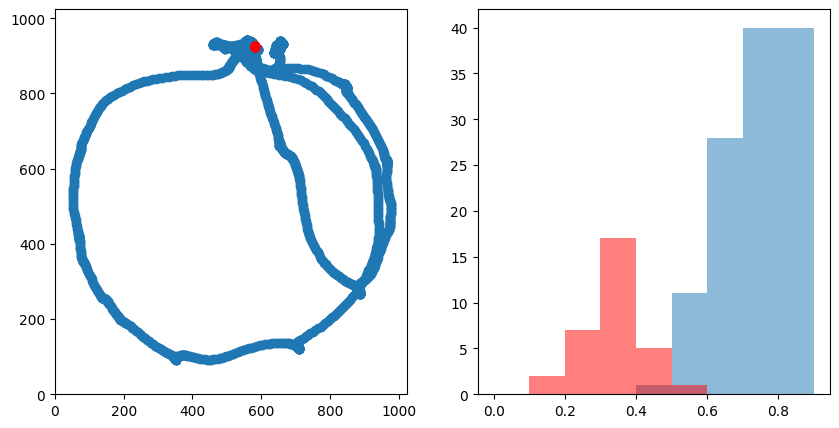

In [ ]:
""" Is .5 a good threshold for whether the animal is moving?"""
import matplotlib.pyplot as plt
moving = (behave > .5).astype(int)
start = np.where(np.diff(moving) == 1)[0]
end = np.where(np.diff(moving) == -1)[0]
idx = 15
if start[0] > end[0]: start = start[1:]
fig, axs = plt.subplots(1,2, figsize = (10,5))
axs[0].scatter(x_pos[start[idx]:end[idx]],y_pos[start[idx]:end[idx]])
axs[0].scatter(x_pos[end[idx]:start[idx+1]],y_pos[end[idx]:start[idx+1]], c = 'r')
axs[0].set_xlim([0,1024])
axs[0].set_ylim([0,1024])
axs[1].hist(behave[start[idx]:end[idx]], bins = np.arange(0,1,.1), alpha = .5)
axs[1].hist(behave[end[idx]:start[idx+1]], bins = np.arange(0,1,.1), alpha = .5, color = 'r')